# Modelo con embeddings de Hugging Face + PyTorch MLP

## Objetivo del notebook

Este notebook tiene como objetivo entrenar un segundo modelo para clasificación de sentimiento financiero utilizando embeddings de Hugging Face y una red neuronal implementada en PyTorch.

---


## 1. Carga del dataset procesado

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [ ]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("mps" if torch.mps.is_available() else "cpu")

device

device(type='cpu')

In [3]:
PATH = Path("../data/processed/financial_phrasebank_processed.csv")
df = pd.read_csv(PATH, encoding="utf-8")
df.head()

,text,label,label_id
0,"According to Gran , the company has no plans t...",neutral,1
1,Technopolis plans to develop in stages an area...,neutral,1
2,The international electronic industry company ...,negative,0
3,With the new production plant the company woul...,positive,2
4,According to the company 's updated strategy f...,positive,2


## 2. Separación de variables

Definimos `X` como los textos financieros y `y` como las etiquetas numéricas de sentimiento.

In [4]:
X = df["text"]
y = df["label_id"]

target_names = ["negative", "neutral", "positive"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (4838,)
y shape: (4838,)


## 3. División train/test

Dividimos los datos de forma estratificada para conservar proporciones similares de clases en entrenamiento y prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (3870,)
X_test: (968,)
y_train: (3870,)
y_test: (968,)


Confirmamos que train y test mantienen una distribución similar de etiquetas.

In [6]:
split_distribution = pd.DataFrame(
    {
        "train_%": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
        "test_%": y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
    }
)

split_distribution

,train_%,test_%
label_id,,
0,12.48,12.5
1,59.35,59.4
2,28.17,28.1


## 4. Carga del modelo de embeddings

Usamos un modelo preentrenado de `sentence-transformers` para convertir cada texto financiero en un vector numérico denso.

In [7]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(embedding_model_name)

embedding_model

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\000207192\Docs\diplo\pfinal\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\000207192\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

## 5. Generación de embeddings

Convertimos los textos de entrenamiento y prueba en vectores numéricos. Estos embeddings serán la entrada del modelo en PyTorch.

In [8]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    convert_to_numpy=True,
    show_progress_bar=True,
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    convert_to_numpy=True,
    show_progress_bar=True,
)

print(f"Train embeddings shape: {X_train_embeddings.shape}")
print(f"Test embeddings shape: {X_test_embeddings.shape}")

Batches:   0%|          | 0/121 [00:00<?, ?it/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Train embeddings shape: (3870, 384)
Test embeddings shape: (968, 384)


## 6. Conversión de etiquetas a arreglos NumPy

PyTorch trabajará con tensores numéricos. Por eso convertimos las etiquetas de entrenamiento y prueba a arreglos de NumPy.

In [14]:
y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

## 7. Dataset personalizado de PyTorch

Creamos una clase `Dataset` para que PyTorch pueda acceder a los embeddings y etiquetas de forma ordenada durante el entrenamiento.

In [11]:
class FinancialSentimentDataset(Dataset):
    """Dataset de PyTorch para embeddings de textos financieros."""

    def __init__(self, embeddings: np.ndarray, labels: np.ndarray):
        """Inicializa el dataset con embeddings y etiquetas."""
        self.embeddings = torch.tensor(embeddings, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        """Regresa el número de observaciones del dataset."""
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Regresa un embedding y su etiqueta correspondiente."""
        return self.embeddings[index], self.labels[index]

Instanciamos los datasets usando los embeddings generados previamente y sus etiquetas correspondientes.

In [13]:
train_dataset = FinancialSentimentDataset(X_train_embeddings, y_train_array)
test_dataset = FinancialSentimentDataset(X_test_embeddings, y_test_array)

## 8. DataLoaders

Los `DataLoader` permiten entrenar el modelo por batches en lugar de procesar todos los datos al mismo tiempo.

In [15]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

first_batch_embeddings, first_batch_labels = next(iter(train_loader))

print(f"Batch embeddings shape: {first_batch_embeddings.shape}")
print(f"Batch labels shape: {first_batch_labels.shape}")

Batch embeddings shape: torch.Size([32, 384])
Batch labels shape: torch.Size([32])


## 9. Definición del modelo MLP

Definimos una red neuronal simple que recibe embeddings como entrada y devuelve tres scores, uno por cada clase de sentimiento.

In [16]:
class SentimentMLP(nn.Module):
    """Red neuronal MLP para clasificación de sentimiento financiero."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.2):
        """Inicializa las capas de la red neuronal.

        Parameters
        ----------
        input_dim : int
            Dimensión del embedding de entrada.
        hidden_dim : int
            Número de neuronas en la capa oculta.
        output_dim : int
            Número de clases de salida.
        dropout : float
            Proporción de neuronas apagadas durante entrenamiento para reducir overfitting.
        """
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Ejecuta el forward pass del modelo.

        Parameters
        ----------
        x : torch.Tensor
            Batch de embeddings.

        Returns
        -------
        torch.Tensor
            Logits para cada clase.
        """
        return self.network(x)

Instanciamos el modelo usando la dimensión real de los embeddings y tres clases de salida: negative, neutral y positive.

In [17]:
INPUT_DIM = X_train_embeddings.shape[1]
HIDDEN_DIM = 128
OUTPUT_DIM = 3
DROPOUT = 0.2

model = SentimentMLP(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT,
).to(device)

model


SentimentMLP(
  (network): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)

## 10. Función de pérdida y optimizador

Usamos CrossEntropyLoss para clasificación multiclase y Adam como optimizador para actualizar los pesos del modelo.

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

## 11. Training loop

Entrenamos el modelo durante varias épocas. En cada época, el modelo procesa batches de embeddings, calcula el error, actualiza sus pesos y registra la pérdida promedio.

In [19]:
EPOCHS = 20

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_embeddings, batch_labels in train_loader:
        batch_embeddings = batch_embeddings.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        logits = model(batch_embeddings)
        loss = criterion(logits, batch_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_embeddings.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS} | Train loss: {epoch_loss:.4f}")

Epoch 1/20 | Train loss: 0.8503
Epoch 2/20 | Train loss: 0.5827
Epoch 3/20 | Train loss: 0.5162
Epoch 4/20 | Train loss: 0.4867
Epoch 5/20 | Train loss: 0.4645
Epoch 6/20 | Train loss: 0.4437
Epoch 7/20 | Train loss: 0.4290
Epoch 8/20 | Train loss: 0.4117
Epoch 9/20 | Train loss: 0.3975
Epoch 10/20 | Train loss: 0.3848
Epoch 11/20 | Train loss: 0.3716
Epoch 12/20 | Train loss: 0.3587
Epoch 13/20 | Train loss: 0.3432
Epoch 14/20 | Train loss: 0.3310
Epoch 15/20 | Train loss: 0.3219
Epoch 16/20 | Train loss: 0.3063
Epoch 17/20 | Train loss: 0.2970
Epoch 18/20 | Train loss: 0.2843
Epoch 19/20 | Train loss: 0.2725
Epoch 20/20 | Train loss: 0.2593


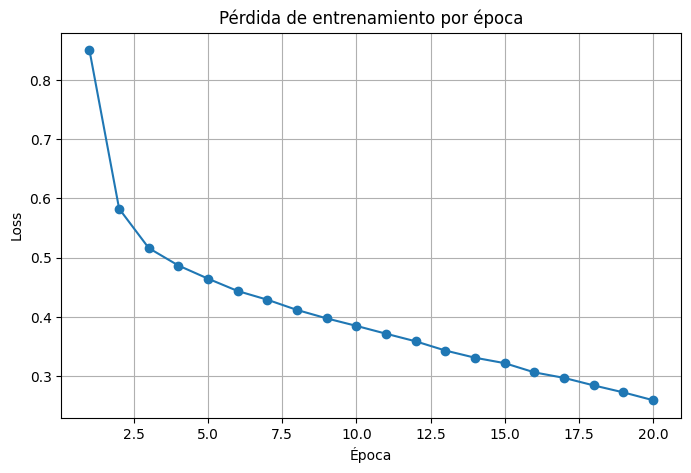

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")

plt.title("Pérdida de entrenamiento por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 12. Evaluación del modelo en test

Evaluamos el modelo con datos que no vio durante el entrenamiento. Para hacerlo, desactivamos el modo entrenamiento y obtenemos predicciones sobre el conjunto de prueba.

In [21]:
model.eval()

all_logits = []
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_embeddings, batch_labels in test_loader:
        batch_embeddings = batch_embeddings.to(device)
        batch_labels = batch_labels.to(device)

        logits = model(batch_embeddings)
        predictions = torch.argmax(logits, dim=1)

        all_logits.append(logits.cpu())
        all_predictions.append(predictions.cpu())
        all_labels.append(batch_labels.cpu())

all_logits = torch.cat(all_logits)
all_predictions = torch.cat(all_predictions).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f"Logits shape: {all_logits.shape}")
print(f"Predictions shape: {all_predictions.shape}")
print(f"Labels shape: {all_labels.shape}")

Logits shape: torch.Size([968, 3])
Predictions shape: (968,)
Labels shape: (968,)


## 13. Probabilidades con softmax

El modelo produce logits, que son scores crudos. Para interpretarlos como probabilidades, aplicamos softmax.

In [22]:
probabilities = torch.softmax(all_logits, dim=1).numpy()

probabilities[:5]

array([[9.6485555e-06, 9.8516315e-01, 1.4827187e-02],
       [1.9017648e-03, 8.9295542e-01, 1.0514276e-01],
       [4.1619046e-03, 9.8416692e-01, 1.1671159e-02],
       [6.6810870e-04, 9.6336424e-01, 3.5967629e-02],
       [9.0844237e-04, 1.4970636e-01, 8.4938520e-01]], dtype=float32)

## 14. Métricas del modelo PyTorch

Calculamos las mismas métricas usadas en el baseline para poder comparar ambos enfoques de forma justa.

In [23]:
mlp_accuracy = accuracy_score(all_labels, all_predictions)
mlp_macro_f1 = f1_score(all_labels, all_predictions, average="macro")
mlp_weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Macro F1: {mlp_macro_f1:.4f}")
print(f"Weighted F1: {mlp_weighted_f1:.4f}")

Accuracy: 0.7727
Macro F1: 0.7326
Weighted F1: 0.7686


In [24]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=target_names,
    )
)

              precision    recall  f1-score   support

    negative       0.67      0.75      0.71       121
     neutral       0.81      0.86      0.84       575
    positive       0.74      0.59      0.65       272

    accuracy                           0.77       968
   macro avg       0.74      0.73      0.73       968
weighted avg       0.77      0.77      0.77       968



## 15. Matriz de confusión

La matriz de confusión permite observar qué clases se están confundiendo entre sí.

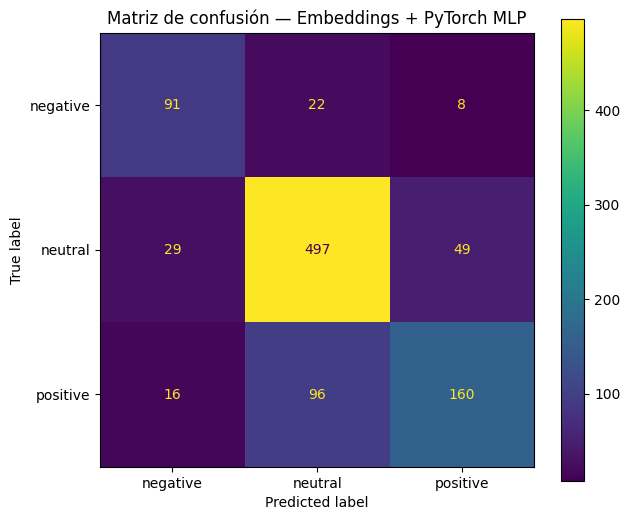

In [25]:
cm_mlp = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=target_names,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Matriz de confusión — Embeddings + PyTorch MLP")
plt.show()

## 16. Comparación contra el baseline TF-IDF

Comparamos el modelo basado en embeddings + PyTorch MLP contra el baseline optimizado de TF-IDF + Logistic Regression.

In [28]:
model_comparison = pd.DataFrame(
    {
        "model": [
            "Optimized TF-IDF + LogisticRegression",
            "Embeddings + PyTorch MLP",
        ],
        "accuracy": [
            0.756198,
            mlp_accuracy,
        ],
        "macro_f1": [
            0.720038,
            mlp_macro_f1,
        ],
        "weighted_f1": [
            0.755463,
            mlp_weighted_f1,
        ],
    }
)

model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Optimized TF-IDF + LogisticRegression,0.756198,0.720038,0.755463
1,Embeddings + PyTorch MLP,0.772727,0.732621,0.768573


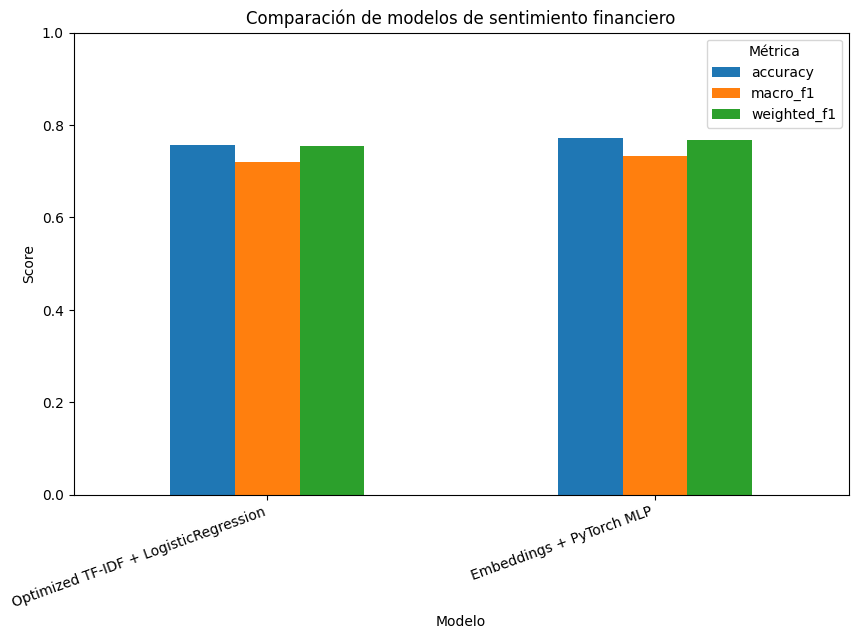

In [29]:
comparison_plot = model_comparison.set_index("model")

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de modelos de sentimiento financiero")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Métrica")
plt.show()